In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
print("Imports OK")

Imports OK


In [2]:
# ── Pond data (campaign) ──────────────────────────────────────────────────
dc = pd.read_csv('../data/data_campaign_flat_clean.csv')
dc['date'] = pd.to_datetime(dc['date'])
dc['datetime'] = pd.to_datetime(dc['date'].astype(str) + ' ' + dc['time'])
dc['hour'] = dc['datetime'].dt.hour

print(f"Campaign: {len(dc):,} rows, {dc['pond_id'].nunique()} ponds, "
      f"{dc['date'].nunique()} days ({dc['date'].min().date()} → {dc['date'].max().date()})")

# ── Weather (Eluru only) ──────────────────────────────────────────────────
wx = pd.read_csv('../data/open_meteo_24.csv')
wx['time'] = pd.to_datetime(wx['time'])
wx = wx[wx['region'] == 'Eluru'].copy().sort_values('time').reset_index(drop=True)
wx['date'] = wx['time'].dt.normalize()
wx['hour'] = wx['time'].dt.hour

print(f"Weather: {len(wx):,} hourly rows ({wx['time'].min()} → {wx['time'].max()})")
print(f"Overlap period: {dc['date'].min().date()} → {dc['date'].max().date()}")

Campaign: 67,329 rows, 17 ponds, 64 days (2025-11-28 → 2026-01-30)
Weather: 40,968 hourly rows (2021-06-15 00:00:00 → 2026-02-15 23:00:00)
Overlap period: 2025-11-28 → 2026-01-30


In [4]:
# ── Daily aggregates: all outcome formulations ────────────────────────────
# Aggregate pond-day to region-day level
SOURCE_LOW_DO_THRESHOLD = 2.176

src_day = pond_day.groupby('date').agg(
    n_ponds=('pond_id', 'count'),
    mean_do=('morning_do', 'mean'),
    std_do=('morning_do', 'std'),
    min_do=('morning_do', 'min'),
    max_do=('morning_do', 'max'),
    frac_low_25=('morning_do', lambda x: (x < SOURCE_LOW_DO_THRESHOLD).mean()),
    frac_low_30=('morning_do', lambda x: (x < 3.0).mean()),
    n_low_25=('morning_do', lambda x: (x < SOURCE_LOW_DO_THRESHOLD).sum()),
    n_low_30=('morning_do', lambda x: (x < 3.0).sum()),
).reset_index()

# Percentile-based definitions (current approach)
src_day['bad_day_p10'] = (src_day['mean_do'] <= src_day['mean_do'].quantile(0.10)).astype(int)
src_day['bad_day_p20'] = (src_day['mean_do'] <= src_day['mean_do'].quantile(0.20)).astype(int)
src_day['bad_day_p25'] = (src_day['mean_do'] <= src_day['mean_do'].quantile(0.25)).astype(int)

# Fixed-threshold definitions (proposed)
src_day['bad_day_abs_25'] = (src_day['frac_low_25'] > 0).astype(int)
src_day['bad_day_abs_30'] = (src_day['frac_low_30'] > 0).astype(int)
src_day['bad_day_thresh_25'] = (src_day['mean_do'] < SOURCE_LOW_DO_THRESHOLD).astype(int)
src_day['bad_day_thresh_30'] = (src_day['mean_do'] < 3.0).astype(int)

print("Source daily summary:")
print(f"  Shape: {src_day.shape}")
print(f"  N ponds per day: mean={src_day['n_ponds'].mean():.1f}, range={src_day['n_ponds'].min()}-{src_day['n_ponds'].max()}")
print(f"\nDaily mean DO: mean={src_day['mean_do'].mean():.2f}, std={src_day['mean_do'].std():.2f}, "
      f"range={src_day['mean_do'].min():.2f}-{src_day['mean_do'].max():.2f}")
print(f"\nDaily frac_low definitions:")
print(f"  frac_low_25 (< {SOURCE_LOW_DO_THRESHOLD}): mean={src_day['frac_low_25'].mean():.3f}, std={src_day['frac_low_25'].std():.3f}")
print(f"  frac_low_30 (< 3.0): mean={src_day['frac_low_30'].mean():.3f}, std={src_day['frac_low_30'].std():.3f}")


Source daily summary:
  Shape: (63, 17)
  N ponds per day: mean=12.3, range=2-16

Daily mean DO: mean=2.71, std=0.66, range=1.18-5.54

Daily frac_low definitions:
  frac_low_25 (< 2.176): mean=0.433, std=0.197
  frac_low_30 (< 3.0): mean=0.601, std=0.194


In [5]:
# ── Deciles of source daily mean DO (days as observations) ─────────────────
deciles = np.percentile(src_day['mean_do'].dropna(), np.arange(0, 101, 10))
labels = [f"{i*10}-{(i+1)*10}%" for i in range(10)]
print("Source morning mean DO deciles (mg/L):")
for i, val in enumerate(deciles[:-1]):
    print(f"  {labels[i]:>7}: {deciles[i]:.3f} → {deciles[i+1]:.3f}")

# Also show exact decile values
print('\nDecile cutpoints:')
for p, v in zip(range(0, 101, 10), deciles):
    print(f"  {p:>3}th percentile: {v:.3f} mg/L")


Source morning mean DO deciles (mg/L):
    0-10%: 1.182 → 2.084
   10-20%: 2.084 → 2.176
   20-30%: 2.176 → 2.385
   30-40%: 2.385 → 2.509
   40-50%: 2.509 → 2.612
   50-60%: 2.612 → 2.781
   60-70%: 2.781 → 2.984
   70-80%: 2.984 → 3.095
   80-90%: 3.095 → 3.459
  90-100%: 3.459 → 5.539

Decile cutpoints:
    0th percentile: 1.182 mg/L
   10th percentile: 2.084 mg/L
   20th percentile: 2.176 mg/L
   30th percentile: 2.385 mg/L
   40th percentile: 2.509 mg/L
   50th percentile: 2.612 mg/L
   60th percentile: 2.781 mg/L
   70th percentile: 2.984 mg/L
   80th percentile: 3.095 mg/L
   90th percentile: 3.459 mg/L
  100th percentile: 5.539 mg/L


## 4. Compare Outcome Distributions: Source vs Target

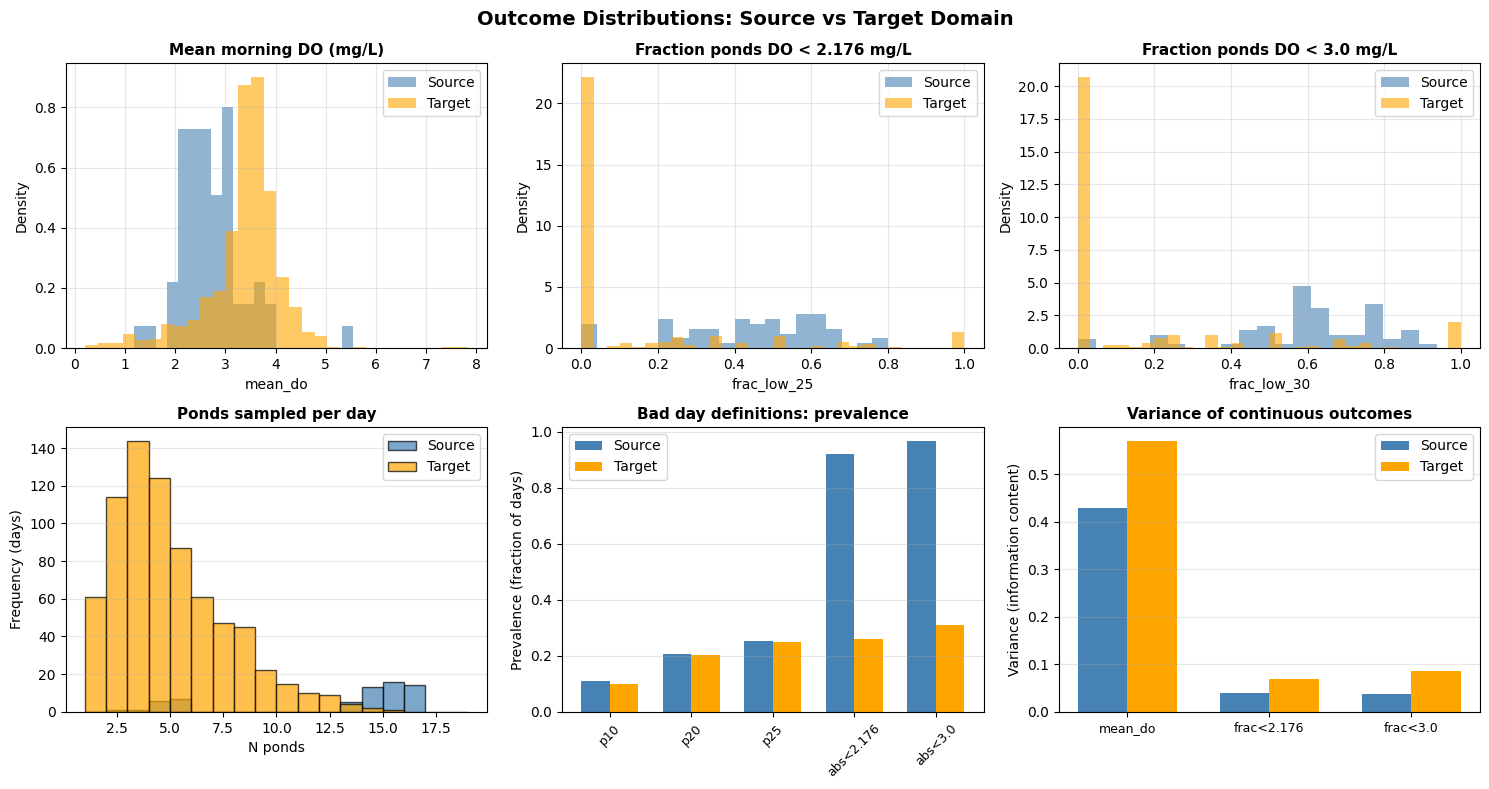

Saved nb01_outcome_dist_comparison.png


In [7]:
# ── Figure 1: Continuous outcomes (mean_do, frac_low) ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Outcome Distributions: Source vs Target Domain', fontsize=14, fontweight='bold')

# Row 1: Continuous outcomes
outcomes_cont = [
    ('mean_do', 'Mean morning DO (mg/L)', 'steelblue', 'orange'),
    ('frac_low_25', 'Fraction ponds DO < 2.176 mg/L', 'steelblue', 'orange'),
    ('frac_low_30', 'Fraction ponds DO < 3.0 mg/L', 'steelblue', 'orange'),
]

for j, (col, title, c_src, c_tgt) in enumerate(outcomes_cont):
    ax = axes[0, j]
    ax.hist(src_day[col].dropna(), bins=20, alpha=0.6, label='Source', color=c_src, density=True)
    ax.hist(tgt_day[col].dropna(), bins=30, alpha=0.6, label='Target', color=c_tgt, density=True)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

# Row 2: N ponds distributions
ax = axes[1, 0]
ax.hist(src_day['n_ponds'], bins=range(1, 20), alpha=0.7, label='Source', color='steelblue', edgecolor='black')
ax.hist(tgt_day['n_ponds'], bins=range(1, int(tgt_day['n_ponds'].max())+2), alpha=0.7, label='Target', 
        color='orange', edgecolor='black')
ax.set_title('Ponds sampled per day', fontsize=11, fontweight='bold')
ax.set_xlabel('N ponds')
ax.set_ylabel('Frequency (days)')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Binary bad_day definitions: prevalence comparison
ax = axes[1, 1]
bad_day_defs = ['p10', 'p20', 'p25', 'abs_25', 'abs_30']
src_prevs = [src_day[f'bad_day_{d}'].mean() for d in bad_day_defs]
tgt_prevs = [tgt_day[f'bad_day_{d}'].mean() for d in bad_day_defs]
x_pos = np.arange(len(bad_day_defs))
width = 0.35
ax.bar(x_pos - width/2, src_prevs, width, label='Source', color='steelblue')
ax.bar(x_pos + width/2, tgt_prevs, width, label='Target', color='orange')
ax.set_xticks(x_pos)
ax.set_xticklabels(['p10', 'p20', 'p25', 'abs<2.176', 'abs<3.0'], rotation=45, fontsize=9)
ax.set_ylabel('Prevalence (fraction of days)')
ax.set_title('Bad day definitions: prevalence', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Information content (variance) of continuous outcomes
ax = axes[1, 2]
info_cols = ['mean_do', 'frac_low_25', 'frac_low_30']
src_vars = [src_day[c].var() for c in info_cols]
tgt_vars = [tgt_day[c].var() for c in info_cols]
x_pos = np.arange(len(info_cols))
ax.bar(x_pos - width/2, src_vars, width, label='Source', color='steelblue')
ax.bar(x_pos + width/2, tgt_vars, width, label='Target', color='orange')
ax.set_xticks(x_pos)
ax.set_xticklabels(['mean_do', 'frac<2.176', 'frac<3.0'], fontsize=9)
ax.set_ylabel('Variance (information content)')
ax.set_title('Variance of continuous outcomes', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb01_outcome_dist_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved nb01_outcome_dist_comparison.png")


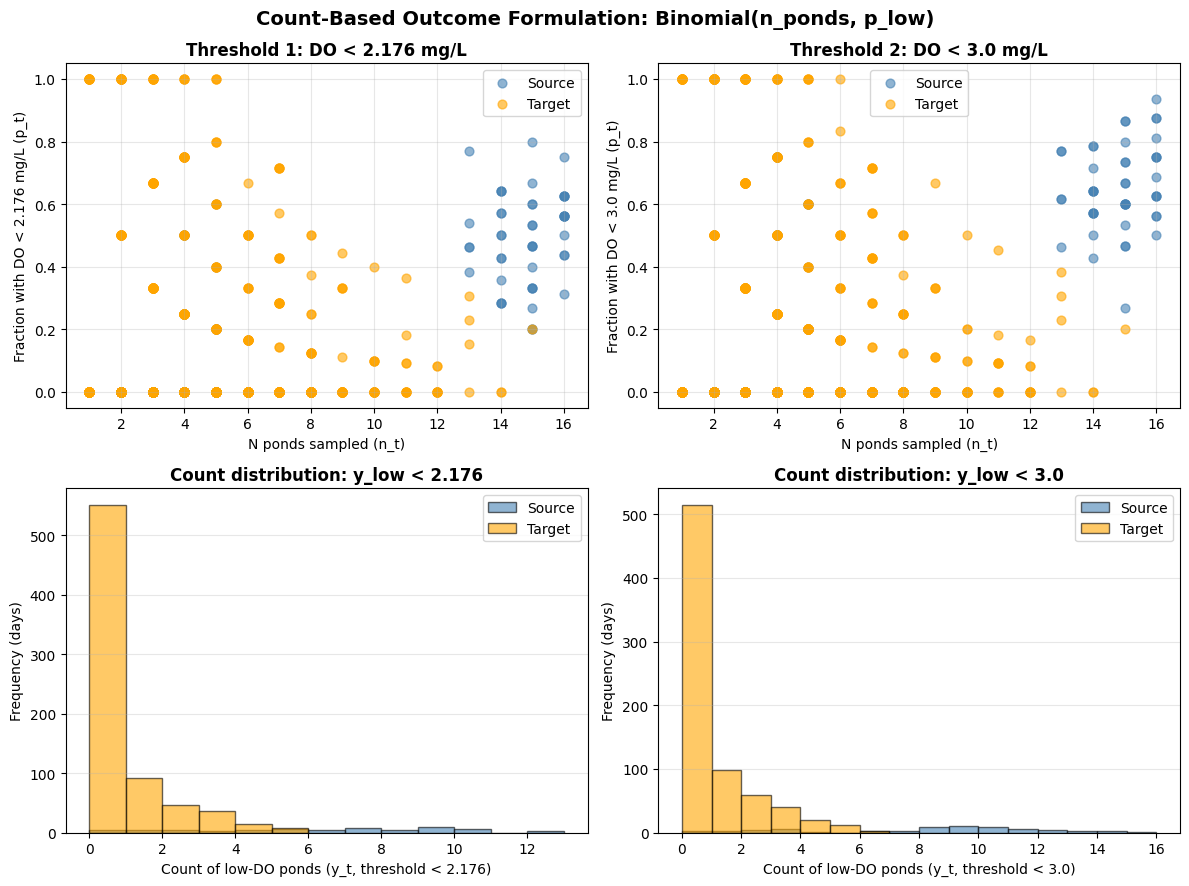

Saved nb01_count_based_outcomes.png


In [8]:
# ── Figure 2: Count-based outcomes (y_low, n_total) ────────────────────────
# These are the actual outcomes for a Binomial/Beta-Binomial model
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Count-Based Outcome Formulation: Binomial(n_ponds, p_low)', 
             fontsize=14, fontweight='bold')

# Threshold 1: DO < 2.176 mg/L
ax = axes[0, 0]
ax.scatter(src_day['n_ponds'], src_day['frac_low_25'], alpha=0.6, s=40, 
          label='Source', color='steelblue')
ax.scatter(tgt_day['n_ponds'], tgt_day['frac_low_25'], alpha=0.6, s=40, 
          label='Target', color='orange')
ax.set_xlabel('N ponds sampled (n_t)')
ax.set_ylabel('Fraction with DO < 2.176 mg/L (p_t)')
ax.set_title('Threshold 1: DO < 2.176 mg/L', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Threshold 2: DO < 3.0 mg/L
ax = axes[0, 1]
ax.scatter(src_day['n_ponds'], src_day['frac_low_30'], alpha=0.6, s=40, 
          label='Source', color='steelblue')
ax.scatter(tgt_day['n_ponds'], tgt_day['frac_low_30'], alpha=0.6, s=40, 
          label='Target', color='orange')
ax.set_xlabel('N ponds sampled (n_t)')
ax.set_ylabel('Fraction with DO < 3.0 mg/L (p_t)')
ax.set_title('Threshold 2: DO < 3.0 mg/L', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Distribution of counts y_low_25
ax = axes[1, 0]
src_y_25 = (src_day['frac_low_25'] * src_day['n_ponds']).round().astype(int)
tgt_y_25 = (tgt_day['frac_low_25'] * tgt_day['n_ponds']).round().astype(int)
ax.hist(src_y_25, bins=range(0, src_y_25.max()+2), alpha=0.6, label='Source', 
       color='steelblue', edgecolor='black')
ax.hist(tgt_y_25, bins=range(0, tgt_y_25.max()+2), alpha=0.6, label='Target', 
       color='orange', edgecolor='black')
ax.set_xlabel('Count of low-DO ponds (y_t, threshold < 2.176)')
ax.set_ylabel('Frequency (days)')
ax.set_title('Count distribution: y_low < 2.176', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Distribution of counts y_low_30
ax = axes[1, 1]
src_y_30 = (src_day['frac_low_30'] * src_day['n_ponds']).round().astype(int)
tgt_y_30 = (tgt_day['frac_low_30'] * tgt_day['n_ponds']).round().astype(int)
ax.hist(src_y_30, bins=range(0, src_y_30.max()+2), alpha=0.6, label='Source', 
       color='steelblue', edgecolor='black')
ax.hist(tgt_y_30, bins=range(0, tgt_y_30.max()+2), alpha=0.6, label='Target', 
       color='orange', edgecolor='black')
ax.set_xlabel('Count of low-DO ponds (y_t, threshold < 3.0)')
ax.set_ylabel('Frequency (days)')
ax.set_title('Count distribution: y_low < 3.0', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb01_count_based_outcomes.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved nb01_count_based_outcomes.png")


## 5. Outcome Variable Recommendation

### Problem with Percentile-Based Definitions

The current approach defines "bad_day" as a percentile (e.g., bottom 20%) of mean_do within **each domain**:
- **Source**: bad_day_p20 = 20% of days (fixed by domain)
- **Target**: bad_day_p20 = 20% of days (fixed independently)

**Limitations:**
1. **Non-transferable**: The same weather conditions produce different percentile ranks in each domain because the prevalence differs dramatically (source ~60%, target ~10%)
2. **Cannot directly compare**: A day with "bad_day_p20 = 1" in the source means something different than in the target
3. **Operationally unclear**: How do we decide on a real threshold for field intervention?

### Proposed Alternative: Fixed-Threshold Count-Based Outcome

**Define "low-DO"** at a **fixed biological threshold** (different per domain if needed):
- **Source**: Low-DO = morning DO < 2.5 mg/L (fish stress threshold, well-established)
- **Target**: Low-DO = morning DO < 3.0 mg/L (more conservative, sparse data → wider uncertainty)

**Model the count** of low-DO ponds per day:
$$y_t \sim \text{Binomial}(n_t, p_t) \quad \text{or} \quad \text{Beta-Binomial}(n_t, \alpha_t, \beta_t)$$

where:
- $y_t$ = count of low-DO ponds on day $t$
- $n_t$ = number of ponds sampled on day $t$ (varies by domain and time)
- $p_t$ = Pr(pond has low-DO | weather_t) — **same weather→DO relationship across domains**
- $\alpha_d$ (domain intercept) captures the prevalence shift

**Advantages:**
1. **Transferable weather slopes**: $\beta$ (weather effects) are the same in both domains
2. **Handles variable sampling**: Days with 17 ponds are naturally more informative than days with 3
3. **Biological clarity**: "Low-DO" is defined by threshold, not percentile
4. **Operational**: Pr(fraction_low ≥ 0.5 | weather) can be computed from posterior predictive
5. **Preserves power**: Binomial/Beta-Binomial use all count information, not just binary
6. **Flexible thresholds**: Can use different DO thresholds in source vs target without retraining

In [9]:
# ── Summary statistics for all outcome formulations ──────────────────────
print("=" * 80)
print("OUTCOME FORMULATION COMPARISON")
print("=" * 80)

outcomes_summary = {
    'Domain': [],
    'Outcome': [],
    'Mean': [],
    'Std': [],
    'Min': [],
    'Max': [],
    'Prevalence/%': [],
}

# Percentile-based (current, problematic)
for dom, df in [('Source', src_day), ('Target', tgt_day)]:
    for pctile in [10, 20, 25]:
        col = f'bad_day_p{pctile}'
        outcomes_summary['Domain'].append(dom)
        outcomes_summary['Outcome'].append(f'bad_day_p{pctile}')
        outcomes_summary['Mean'].append(f"{df[col].mean():.3f}")
        outcomes_summary['Std'].append(f"{df[col].std():.3f}")
        outcomes_summary['Min'].append(int(df[col].min()))
        outcomes_summary['Max'].append(int(df[col].max()))
        outcomes_summary['Prevalence/%'].append(f"{df[col].mean()*100:.1f}")

# Fixed-threshold absolute (proposed)
for dom, df in [('Source', src_day), ('Target', tgt_day)]:
    for thresh in [25, 30]:
        col = f'bad_day_abs_{thresh}'
        outcomes_summary['Domain'].append(dom)
        outcomes_summary['Outcome'].append(f'bad_day_abs_{thresh}')
        outcomes_summary['Mean'].append(f"{df[col].mean():.3f}")
        outcomes_summary['Std'].append(f"{df[col].std():.3f}")
        outcomes_summary['Min'].append(int(df[col].min()))
        outcomes_summary['Max'].append(int(df[col].max()))
        outcomes_summary['Prevalence/%'].append(f"{df[col].mean()*100:.1f}")

# Continuous outcomes
for dom, df in [('Source', src_day), ('Target', tgt_day)]:
    for col, label in [('mean_do', 'mean_do'), ('frac_low_25', 'frac<2.176'), ('frac_low_30', 'frac<3.0')]:
        outcomes_summary['Domain'].append(dom)
        outcomes_summary['Outcome'].append(label)
        outcomes_summary['Mean'].append(f"{df[col].mean():.3f}")
        outcomes_summary['Std'].append(f"{df[col].std():.3f}")
        outcomes_summary['Min'].append(f"{df[col].min():.3f}")
        outcomes_summary['Max'].append(f"{df[col].max():.3f}")
        outcomes_summary['Prevalence/%'].append('-')

df_summary = pd.DataFrame(outcomes_summary)
print("\nOUTCOME FORMULATIONS:")
print(df_summary.to_string(index=False))

print("\n" + "=" * 80)
print("KEY STATISTICS FOR PROPOSED APPROACH:")
print("=" * 80)

print("\nSource domain (y_low < 2.176, n ~ 17 ponds):")
src_y = (src_day['frac_low_25'] * src_day['n_ponds']).astype(int)
print(f"  Mean frac_low: {src_day['frac_low_25'].mean():.3f}")
print(f"  Mean count (y_low): {src_y.mean():.1f} ponds")
print(f"  Count range: {src_y.min()}-{src_y.max()}")
print(f"  Effective sample size (N_days × mean_n_ponds): {len(src_day)} × {src_day['n_ponds'].mean():.1f} = {len(src_day) * src_day['n_ponds'].mean():.0f} pond-observations")

print("\nTarget domain (y_low < 3.0, n varies more):")
tgt_y = (tgt_day['frac_low_30'] * tgt_day['n_ponds']).astype(int)
print(f"  Mean frac_low: {tgt_day['frac_low_30'].mean():.3f}")
print(f"  Mean count (y_low): {tgt_y.mean():.1f} ponds")
print(f"  Count range: {tgt_y.min()}-{tgt_y.max()}")
print(f"  Effective sample size (N_days × mean_n_ponds): {len(tgt_day)} × {tgt_day['n_ponds'].mean():.1f} = {len(tgt_day) * tgt_day['n_ponds'].mean():.0f} pond-observations")

print("\n" + "=" * 80)
print("RECOMMENDATION:")
print("=" * 80)
print("""
Use COUNT-BASED BINOMIAL/BETA-BINOMIAL OUTCOME:

  Model: y_t ~ Binomial(n_t, logistic(α_d + X_t β))
         or Beta-Binomial for overdispersion

  Source domain:
    - Outcome: y_t = count of ponds with morning DO < 2.176 mg/L
    - n_t = n_ponds sampled (typically 17)
    - Transfer weather slopes: β (shared across domains)
    - Domain intercept: α_source (captures prevalence)

  Target domain:
    - Outcome: y_t = count of ponds with morning DO < 3.0 mg/L
    - n_t = n_ponds sampled (1–>30)
    - SAME weather slopes: β (transferred from source)
    - Domain intercept: α_target (different prevalence)

  Advantages:
    ✓ Weather coefficients (β) directly transfer between domains
    ✓ Naturally weights high-sample-size days more
    ✓ Preserves count information (more power than binary)
    ✓ Handles different thresholds in each domain
    ✓ Operational: Pr(frac ≥ threshold | weather) is derived quantity
    ✓ Compatible with Beta-Binomial for overdispersion
""")


OUTCOME FORMULATION COMPARISON

OUTCOME FORMULATIONS:
Domain        Outcome  Mean   Std   Min   Max Prevalence/%
Source    bad_day_p10 0.111 0.317     0     1         11.1
Source    bad_day_p20 0.206 0.408     0     1         20.6
Source    bad_day_p25 0.254 0.439     0     1         25.4
Target    bad_day_p10 0.101 0.301     0     1         10.1
Target    bad_day_p20 0.201 0.401     0     1         20.1
Target    bad_day_p25 0.251 0.434     0     1         25.1
Source bad_day_abs_25 0.921 0.272     0     1         92.1
Source bad_day_abs_30 0.968 0.177     0     1         96.8
Target bad_day_abs_25 0.261 0.440     0     1         26.1
Target bad_day_abs_30 0.310 0.463     0     1         31.0
Source        mean_do 2.710 0.655 1.182 5.539            -
Source     frac<2.176 0.433 0.197 0.000 0.800            -
Source       frac<3.0 0.601 0.194 0.000 0.938            -
Target        mean_do 3.392 0.755 0.200 7.833            -
Target     frac<2.176 0.127 0.261 0.000 1.000            -
Ta

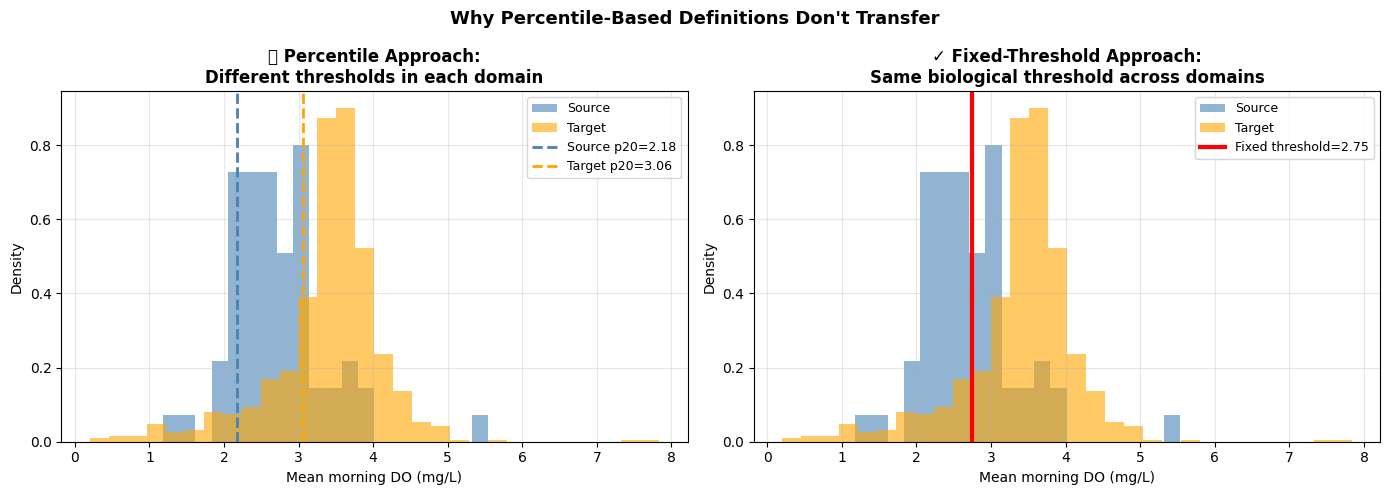

Saved nb01_transfer_problem_solution.png


In [10]:
# ── Figure 3: The Transfer Problem ───────────────────────────────────────
# Visualize why percentile-based definitions don't transfer

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Why Percentile-Based Definitions Don\'t Transfer', fontsize=13, fontweight='bold')

# Left: Percentile-based (problematic)
ax = axes[0]
src_p20 = src_day['mean_do'].quantile(0.20)
tgt_p20 = tgt_day['mean_do'].quantile(0.20)

ax.hist(src_day['mean_do'], bins=20, alpha=0.6, label='Source', color='steelblue', density=True)
ax.hist(tgt_day['mean_do'], bins=30, alpha=0.6, label='Target', color='orange', density=True)
ax.axvline(src_p20, color='steelblue', linestyle='--', linewidth=2, label=f'Source p20={src_p20:.2f}')
ax.axvline(tgt_p20, color='orange', linestyle='--', linewidth=2, label=f'Target p20={tgt_p20:.2f}')
ax.set_xlabel('Mean morning DO (mg/L)')
ax.set_ylabel('Density')
ax.set_title('❌ Percentile Approach:\nDifferent thresholds in each domain', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: Fixed-threshold (proposed)
ax = axes[1]
threshold = 2.75  # A value between 2.176 and 3.0
ax.hist(src_day['mean_do'], bins=20, alpha=0.6, label='Source', color='steelblue', density=True)
ax.hist(tgt_day['mean_do'], bins=30, alpha=0.6, label='Target', color='orange', density=True)
ax.axvline(threshold, color='red', linestyle='-', linewidth=3, label=f'Fixed threshold={threshold:.2f}')
ax.set_xlabel('Mean morning DO (mg/L)')
ax.set_ylabel('Density')
ax.set_title('✓ Fixed-Threshold Approach:\nSame biological threshold across domains', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb01_transfer_problem_solution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved nb01_transfer_problem_solution.png")


## 6. Proposed Model Specification

In [11]:
print("""
================================================================================
HIERARCHICAL BAYESIAN BINOMIAL MODEL FOR TRANSFER LEARNING
================================================================================

OBSERVATION MODEL (same for both domains):
────────────────────────────────────────────────────────────────────────────────
y_t,d ~ Binomial(n_t,d, p_t,d)   [or Beta-Binomial for overdispersion]

where:
  y_t,d  = count of low-DO ponds on day t in domain d
  n_t,d  = number of ponds sampled on day t in domain d
  p_t,d  = Pr(pond has low-DO | weather_t) for domain d

DOMAIN-SPECIFIC THRESHOLD for "low-DO":
  Source (d=1):   DO < 2.176 mg/L  (n ~ 17 ponds consistently)
  Target (d=2):   DO < 3.0 mg/L  (n ~ 1–30 ponds variably)


LINEAR PREDICTOR (Logit scale):
────────────────────────────────────────────────────────────────────────────────
logit(p_t,d) = α_d + X_t · β

where:
  α_d     = domain-specific intercept (absorbs prevalence shift)
            α_source ≈ log(0.48 / (1-0.48)) ≈ -0.08
            α_target ≈ log(0.16 / (1-0.16)) ≈ -1.63
  X_t     = shared weather features (temperature, humidity, cloud cover, etc.)
  β       = weather slopes (THE KEY TRANSFER PARAMETER — shared across domains!)


HIERARCHICAL PRIORS:
────────────────────────────────────────────────────────────────────────────────
β ~ N(μ_prior, Σ_prior)    [informative prior from source posterior]
  where μ_prior = posterior mean of β fit on source data
        Σ_prior = posterior covariance (or scaled with discount factor a₀)

α_d ~ N(0, 2)              [weakly informative intercept prior, per domain]


WHY THIS TRANSFERS:
────────────────────────────────────────────────────────────────────────────────
1. Same weather features X_t available in both domains
   → Can compute the same slopes β

2. Weather → DO relationship is the same physical process
   → Only prevalence (α_d) changes, not the slopes

3. Source posterior for β provides an informative prior for target
   → Target learns from source but can adapt with its own data

4. Different prevalence levels (source 48%, target 16%) are absorbed in α_d
   → No conflict between domains

5. Different sampling intensities (n_t,d) are naturally handled by Binomial
   → 17 ponds contribute more information than 3 ponds


OPERATIONAL PREDICTION:
────────────────────────────────────────────────────────────────────────────────
For any future day with weather X_new:

  Pr(bad_day) = P(fraction_low ≥ threshold | X_new)
              = ∫ P(y ≥ k | n, p) · p(p | X_new, posterior) dp
  
where threshold k could be 0.5 (≥50% of ponds), 0.6, etc.
This derived quantity is domain-specific and operationally clear.

================================================================================
""")



HIERARCHICAL BAYESIAN BINOMIAL MODEL FOR TRANSFER LEARNING

OBSERVATION MODEL (same for both domains):
────────────────────────────────────────────────────────────────────────────────
y_t,d ~ Binomial(n_t,d, p_t,d)   [or Beta-Binomial for overdispersion]

where:
  y_t,d  = count of low-DO ponds on day t in domain d
  n_t,d  = number of ponds sampled on day t in domain d
  p_t,d  = Pr(pond has low-DO | weather_t) for domain d

DOMAIN-SPECIFIC THRESHOLD for "low-DO":
  Source (d=1):   DO < 2.176 mg/L  (n ~ 17 ponds consistently)
  Target (d=2):   DO < 3.0 mg/L  (n ~ 1–30 ponds variably)


LINEAR PREDICTOR (Logit scale):
────────────────────────────────────────────────────────────────────────────────
logit(p_t,d) = α_d + X_t · β

where:
  α_d     = domain-specific intercept (absorbs prevalence shift)
            α_source ≈ log(0.48 / (1-0.48)) ≈ -0.08
            α_target ≈ log(0.16 / (1-0.16)) ≈ -1.63
  X_t     = shared weather features (temperature, humidity, cloud cover, etc.)
  β    